# LightGBM Stock Price Forecasting (IDX30)
This notebook trains a LightGBM regressor to predict the **next-day closing price** using lag/rolling and calendar features. It reports **MAE/RMSE** (absolute and %) and plots **Actual vs Predicted**.

In [3]:
# ================================
# 1) Setup
# ================================
# If you are running on Colab and LightGBM is not installed, uncomment the next line:
# !pip install lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (16, 5)

In [4]:
# ================================
# 2) Load dataset
# ================================
file_path = "CS-IDX30 version 3/CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx"  # change if needed
df_raw = pd.read_excel("CS-IDX30 version 3/CS-IDX30 version 3/CS-IDX30 version 3/pricehistory data/Finance/BBCA.JK_dataprice.xlsx")

# Basic formatting
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df_raw = df_raw.sort_values("Date").reset_index(drop=True)

# Keep standard OHLCV columns (Dividends & Stock Splits are typically all-zero and unused)
df = df_raw[["Date", "Open", "High", "Low", "Close", "Volume"]].copy()

# Ensure numeric & handle rare missing values (lightweight because data is already clean)
for col in ["Open","High","Low","Close","Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[["Open","High","Low","Close","Volume"]] = df[["Open","High","Low","Close","Volume"]].interpolate(method="linear")
df[["Open","High","Low","Close","Volume"]] = df[["Open","High","Low","Close","Volume"]].ffill().bfill()

df.head()

,Date,Open,High,Low,Close,Volume
0,2017-07-31,3435.631645,3477.191706,3431.013861,3454.102783,65311000.0
1,2017-08-01,3486.427273,3504.898411,3458.720566,3495.662842,88810000.0
2,2017-08-02,3495.662842,3504.898411,3477.191704,3495.662842,62681500.0
3,2017-08-03,3518.751793,3518.751793,3426.396103,3463.338379,43917500.0
4,2017-08-04,3463.338654,3463.338654,3426.396375,3431.014160,70007000.0


In [5]:
# ================================
# 3) Feature engineering (tabular supervised format)
# ================================
MAX_LAG = 30          # how many previous days to use as lag features
TEST_SIZE = 120       # last 120 trading days as test

# Returns (helps with non-stationarity)
df["ret_1"] = df["Close"].pct_change()
df["ret_5"] = df["Close"].pct_change(5)

# Lag features (Close & Volume)
for lag in [1, 2, 3, 5, 10, 20, 30]:
    df[f"Close_lag_{lag}"] = df["Close"].shift(lag)
    df[f"Volume_lag_{lag}"] = df["Volume"].shift(lag)

# Rolling features (momentum + volatility)
for w in [5, 10, 20, 30]:
    df[f"Close_MA_{w}"] = df["Close"].rolling(w).mean()
    df[f"Close_STD_{w}"] = df["Close"].rolling(w).std()

# Calendar features
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month

# Target = next-day Close, and its corresponding date (so plots align correctly)
df["target_Close"] = df["Close"].shift(-1)
df["target_Date"] = df["Date"].shift(-1)

# Drop rows made invalid by lag/rolling/shift
df_feat = df.dropna().reset_index(drop=True)

# Define features
drop_cols = ["Date", "target_Close", "target_Date"]
feature_cols = [c for c in df_feat.columns if c not in drop_cols]

# Train/Test split (chronological)
train_df = df_feat.iloc[:-TEST_SIZE].copy()
test_df  = df_feat.iloc[-TEST_SIZE:].copy()

X_train = train_df[feature_cols]
y_train = train_df["target_Close"].values

X_test  = test_df[feature_cols]
y_true  = test_df["target_Close"].values
test_dates = test_df["target_Date"].values  # aligns with next-day target

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Features:", len(feature_cols))

Train rows: 1105 Test rows: 120
Features: 31


In [6]:
# ================================
# 4) Train LightGBM
# ================================
# A stronger baseline configuration than n_estimators=100
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)

# Use the last part of training data as a validation set for early stopping
val_size = min(120, max(30, int(0.1 * len(train_df))))
X_tr, X_val = X_train.iloc[:-val_size], X_train.iloc[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
)

print("Best iteration:", model.best_iteration_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7409
[LightGBM] [Info] Number of data points in the train set: 995, number of used features: 31
[LightGBM] [Info] Start training from score 5276.454081
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [7]:
# ================================
# 5) Predict + metrics (MAE/RMSE and %)
# ================================
y_pred = model.predict(X_test, num_iteration=model.best_iteration_)

MAE = mean_absolute_error(y_true, y_pred)
RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
mean_price = np.mean(y_true)

MAE_percent = (MAE / mean_price) * 100
RMSE_percent = (RMSE / mean_price) * 100

print("\n===== LightGBM Performance Metrics (Next-Day Forecast, Last 120 Days) =====")
print(f"MAE  : {MAE:,.2f}   ({MAE_percent:.2f}%)")
print(f"RMSE : {RMSE:,.2f}   ({RMSE_percent:.2f}%)")


===== LightGBM Performance Metrics (Next-Day Forecast, Last 120 Days) =====
MAE  : 848.05   (11.16%)
RMSE : 894.59   (11.77%)


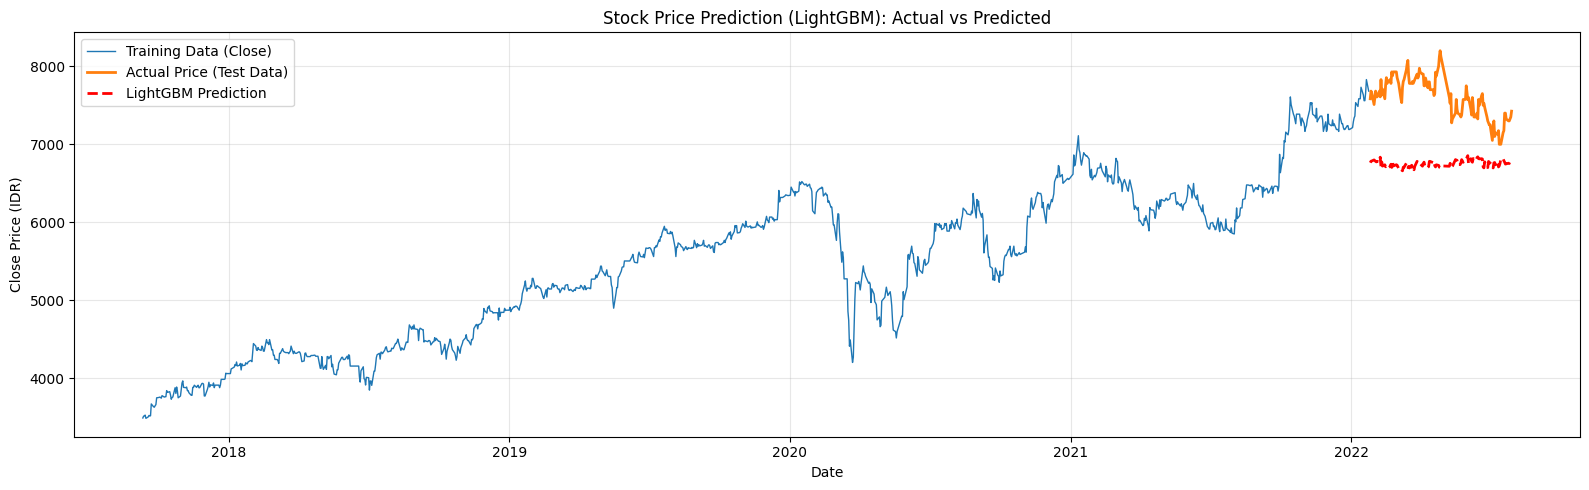

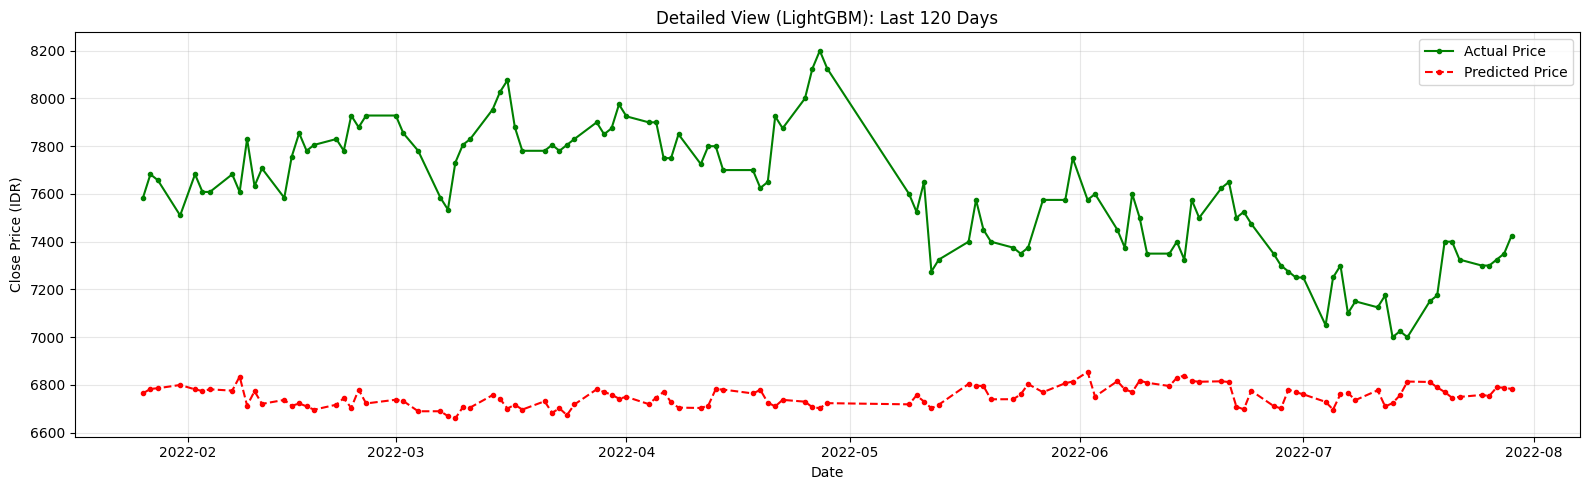

In [8]:
# ================================
# 6) Plots (full + zoom)
# ================================
# Full plot: training Close + test actual/predicted (next-day targets)
plt.figure(figsize=(16, 5))

plt.plot(train_df["Date"], train_df["Close"], label="Training Data (Close)", linewidth=1)
plt.plot(test_dates, y_true, label="Actual Price (Test Data)", linewidth=2)
plt.plot(test_dates, y_pred, "r--", label="LightGBM Prediction", linewidth=2)

plt.title("Stock Price Prediction (LightGBM): Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Close Price (IDR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Zoom plot: last 120 days only
plt.figure(figsize=(16, 5))

plt.plot(test_dates, y_true, "g.-", label="Actual Price")
plt.plot(test_dates, y_pred, "r.--", label="Predicted Price")

plt.title("Detailed View (LightGBM): Last 120 Days")
plt.xlabel("Date")
plt.ylabel("Close Price (IDR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()